In [1]:
import torch
import os
import sys
sys.path.append(os.getcwd() + "/../model")
from swinv2_encoder import SwinTransformerV2, PatchEmbed

torch.set_printoptions(linewidth=10000000, threshold=300000000)

/home/charles/.local/share/virtualenvs/sarformer-MbrRxyej/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
patch_embed = PatchEmbed()
encoder = SwinTransformerV2(mask_proportion=0.75)

x = torch.randint(255, size=(224, 224, 3), dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
x = patch_embed(x)
masked_input, x = encoder.mask(x)

/home/charles/.local/share/virtualenvs/sarformer-4YlcbT5g/lib/python3.10/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [3]:
print(x.shape)
x

torch.Size([1, 1, 784, 96])


tensor([[[[-1.5595e+01,  2.0728e+01,  6.3457e+01,  9.4102e+01, -4.0274e+01,  6.5553e+01, -2.7917e+01, -7.2682e+01,  1.7333e+01, -1.7812e+01,  2.5326e-02, -8.8371e+01,  9.3443e+01, -7.2491e+01, -3.5210e+01, -1.0104e+01, -1.2649e+01,  9.3542e+00, -3.0436e+01,  4.5949e+01, -6.6929e+00, -5.7768e+01,  9.8857e+01,  7.0256e+00, -4.6919e+01, -6.8528e-03, -5.3828e+00, -1.1496e+02,  7.8455e+00, -3.8241e+00,  7.1355e+01, -2.1888e+02,  7.1089e+01, -8.2317e+01, -7.8541e+01, -1.2555e+02, -3.9385e+01,  6.1718e+01,  4.2903e+01, -6.6213e+01, -6.4029e+01, -4.3549e+01, -2.5534e+01,  1.4873e+02, -4.7967e+01, -2.1250e-01,  4.4100e+01,  1.3279e+02,  1.3567e+02,  4.6894e+01, -2.5181e+02, -6.3362e-01,  2.3924e+01,  5.1966e+01, -9.7820e+01,  2.0801e+02,  4.6819e+01,  5.1416e+00,  1.6342e+00,  3.7239e+01,  3.3910e+01,  3.2444e+01, -1.0874e+02, -1.0632e+02, -2.7445e+01, -5.8655e+01,  5.7524e+01, -5.5093e+01, -3.8866e+01,  1.1116e+01, -4.8248e+00, -1.6954e+01, -4.4112e+01, -5.9197e+01,  6.6980e+01,  5.6254e+01,  

In [19]:
from time import time

start = time()
indices_kept = torch.sort(
    torch.randint(10 - 3, size=(4, 3)), axis=1
).values + torch.arange(3)
end = time()
print(f"took {end - start} seconds")

took 0.0009670257568359375 seconds


In [13]:
# see https://discuss.pytorch.org/t/batch-version-of-torch-randperm/111121
start = time()
indices_kept = torch.stack([torch.randperm(10)[:3] for _ in range(4)], dim=0).shape
end = time()
print(f"took {end - start} seconds")

took 0.0010380744934082031 seconds


In [7]:
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor, to_pil_image

im = Image.open("NAIP_258770.jpg")
x = pil_to_tensor(im).unsqueeze(0)

swin = SwinTransformerV2(
    img_size=512, patch_size=4, window_size=4, mask_token=0, mask_proportion=0.75
)
embed_x, x = swin.mask(x)
embed_x = embed_x.squeeze(0)
x = x.reshape(3, 512, -1)

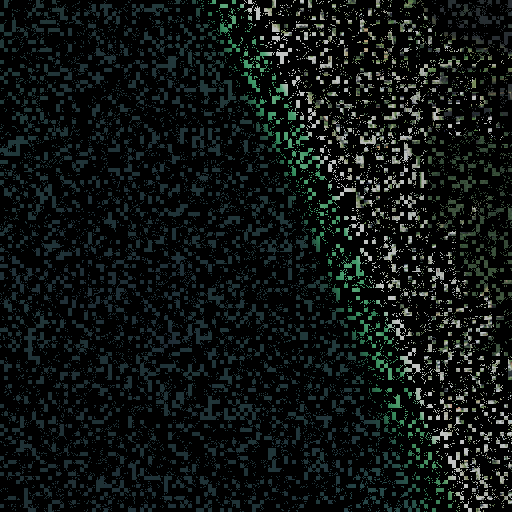

In [8]:
out1 = to_pil_image(embed_x)
out2 = to_pil_image(x)
out1

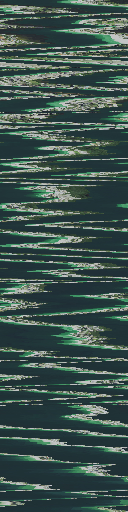

In [5]:
out2